In [ ]:
import Pkg; Pkg.add("StatsPlots")

In [2]:
using Pkg
Pkg.activate(pwd())
Pkg.instantiate()

using StatsPlots
using StatsBase
using Random
using Statistics

using Plots
include("ed.jl")

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/QuIST/Projekt-Praktikum/codebase/groundstate_prep/plotting_environment`
Precompiling packages...
   5731.7 ms  ✓ Qt6ShaderTools_jll
   5753.2 ms  ✓ Qt6Svg_jll
   2448.4 ms  ✓ Qt6Declarative_jll
   8510.4 ms  ✓ Pango_jll
  12226.0 ms  ✓ Interpolations → InterpolationsUnitfulExt
   7749.8 ms  ✓ GR_jll
   3668.9 ms  ✓ GR
  61388.1 ms  ✓ Plots
   3881.7 ms  ✓ Plots → UnitfulExt
  32279.2 ms  ✓ StatsPlots
  10 dependencies successfully precompiled in 119 seconds. 265 already precompiled.
[ Info: Precompiling StatsPlots [f3b207a7-027a-5e70-b257-86293d7955fd] (cache misses: wrong dep version loaded (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught excep

get_spectrum (generic function with 1 method)

gap: 0.11
bandwidth: 1.854


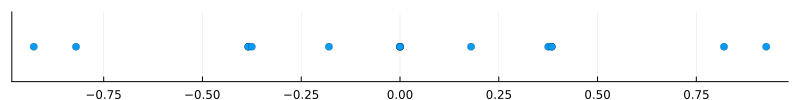

gap: 0.06
bandwidth: 1.83


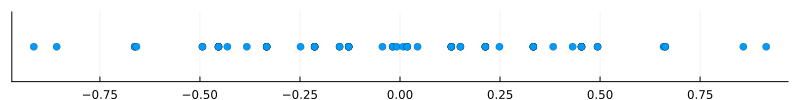

gap: 0.04
bandwidth: 1.823


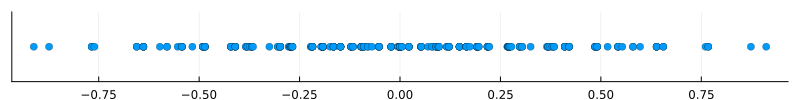

In [3]:

J, h = 1, 1.2
norm = sqrt(J^2+h^2)

Ns = [4,6,8]

s = [Float64[] for _ in Ns]

for i in 1:3
    N = Ns[i]
    norm = N*sqrt(J^2+h^2)

    H = transverse_ising_hamiltonian(N, J/norm, h/norm);

    s[i] = get_spectrum(H)
    spectrum = s[i]
    println("gap: ", round(spectrum[2]-spectrum[1], digits =2))
    println("bandwidth: ", round(spectrum[end]-spectrum[1],digits=3))

    display(scatter(spectrum, zeros(length(spectrum)), ylim=(-1,1),yticks=false, ylabel="", label="", aspect_ratio=:auto, size=(800,100)))
end


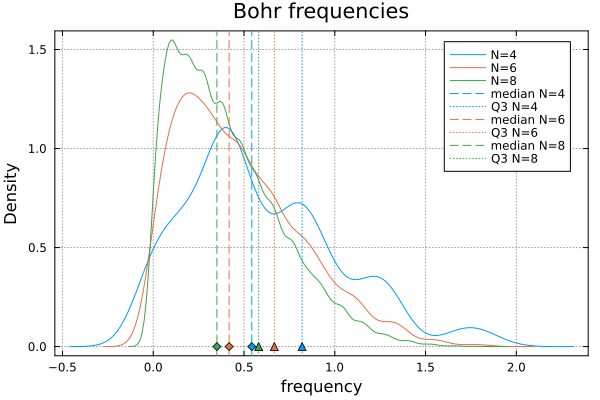

3-element Vector{Vector{Float64}}:
 [0.37515882973440284, 0.5428499054632524, 0.8200921998322421]
 [0.2050230609540036, 0.4180858021221201, 0.6670011228425089]
 [0.1687627687620401, 0.35064872130338987, 0.5806744438119757]

In [6]:
bohrs = [Float64[] for _ in s]

for k in eachindex(s)
    spectrum = s[k]
    for i in 1:(length(spectrum)-1)
        for j in (i+1):length(spectrum)
            push!(bohrs[k], spectrum[j]-spectrum[i])
            if bohrs[k][end] < 0
                println(i,j, bohrs[k][end])
            end
        end
    end
end

colors = palette(:default)[1:length(bohrs)]

p = density(bohrs[1]; label="N=$(Ns[1])", xlabel="frequency", ylabel="Density", color=colors[1], title="Bohr frequencies")
for k in 2:length(bohrs)
    density!(p, bohrs[k]; label="N=$(Ns[k])", color=colors[k])
end

medians = median.(bohrs)
third_quartiles = [quantile(bohr, 0.75) for bohr in bohrs]
for k in eachindex(medians)
    vline!(p, [medians[k]]; label="median N=$(Ns[k])", linestyle=:dash, color=colors[k])
    scatter!(p, [medians[k]], [0.0]; label="", marker=:diamond, color=colors[k])
    vline!(p, [third_quartiles[k]]; label="Q3 N=$(Ns[k])", linestyle=:dot, color=colors[k])
    scatter!(p, [third_quartiles[k]], [0.0]; label="", marker=:utriangle, color=colors[k])
end
plot!(p; framestyle=:box, grid=true, xgrid=true, ygrid=true, gridalpha=0.45, gridlinewidth=1, gridstyle=:dot, foreground_color_grid=:gray, foreground_color_axis=:black, foreground_color_border=:black)
savefig("docu/plots/bohr_density_plot.png")
display(p)

quantile.(bohrs, Ref([0.25, 0.5, 0.75]))  # 25%, 50% (median), and 75% quantiles

In [86]:
h = fit(Histogram, bohr, nbins=30)
peak_bin = argmax(h.weights)
h.edges[1][peak_bin]

0.0

In [7]:
Ns = [4, 6, 8]
num_J = 20
h = 1
Js = [0.1*i for i in 1:num_J]

all_qs = Dict{Int, Vector{Vector{Float64}}}()

for N in Ns
    qs = [Float64[] for _ in Js]

    for l in eachindex(Js)
        J = Js[l]
        norm = sqrt(J^2 + h^2)
        H = transverse_ising_hamiltonian(N, J/norm, h/norm)
        spectrum = get_spectrum(H)

        bohr = Float64[]
        for i in 1:(length(spectrum)-1)
            for j in (i+1):length(spectrum)
                push!(bohr, spectrum[j] - spectrum[i])
            end
        end

        qs[l] = quantile(bohr, [0.5, 0.75, 1.0])
    end

    all_qs[N] = qs
end


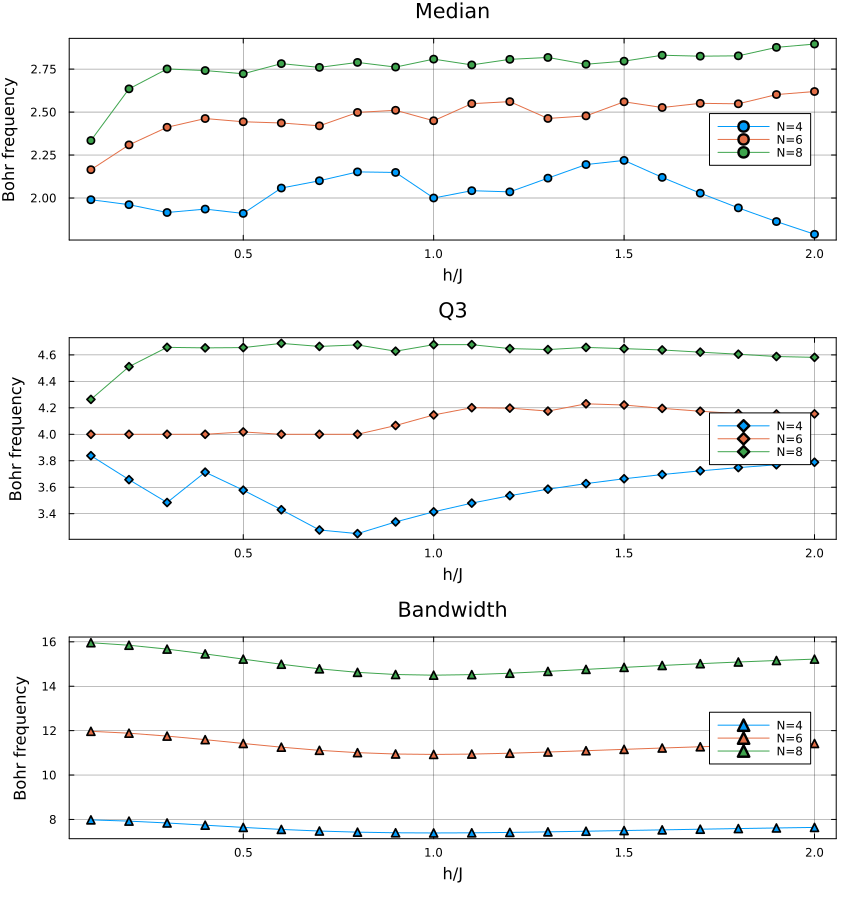

In [10]:

colors = palette(:default)[1:length(Ns)]
linestyles = [:solid, :dash, :dot]

p = plot(
    layout=(3, 1),
    size=(850, 900),
    xlabel="h/J",
    ylabel="Bohr frequency",
    title=["Median" "Q3" "Bandwidth"],
    legend=:right,
)

for (idx, N) in enumerate(Ns)
    qs = all_qs[N]
    medians = [q[1] for q in qs]
    q75s = [q[2] for q in qs]
    bandwidths = [q[3] for q in qs]

    plot!(p[1], Js, medians; label="N=$N", color=colors[idx], marker=:circle)
    plot!(p[2], Js, q75s; label="N=$N", color=colors[idx], marker=:diamond)
    plot!(p[3], Js, bandwidths; label="N=$N", color=colors[idx], marker=:utriangle)
end

plot!(p; framestyle=:box, grid=true, gridalpha=0.3)
savefig("docu/bohr_quantiles_plot")
display(p)
